In [1]:
#tHE Clothing Fashion-MNIST is a dataset of images from Zalando (Europe's biggest online fashion retailer)
# it consists of 60000 training samples and 10000 testing samples
# Each sample is a 28*28 grayscale image associated with a label from 10 classes
# http://yann.lecun.com/exdb/mnist/

10 classes are:


1.   T-shirt/top

1.   Trouser

1.   Pullover

1.   Dress

1.   Coat

1.   Sandal
2.   Shirt


2.   Sneaker


2.   bag


2.   Ankle Boot





In [2]:
import tensorflow as tf
fashion_mnist = tf.keras.datasets.fashion_mnist

In [3]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
print(train_labels)

[9 0 0 ... 3 0 5]


In [5]:
# define classname
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [6]:
print(train_images.shape)

(60000, 28, 28)


In [7]:
print(test_images.shape)

(10000, 28, 28)


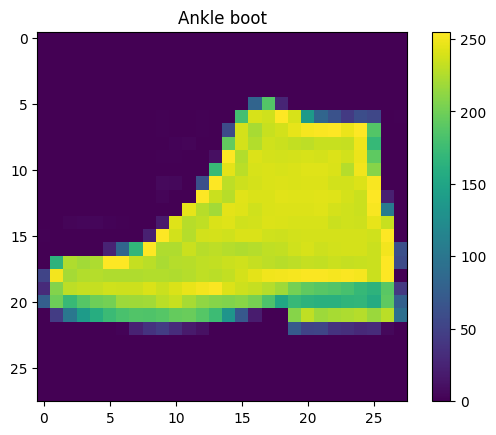

In [8]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(train_images[42])
plt.colorbar()
plt.grid(False)
plt.title(class_names[train_labels[42]])
plt.show()

In [9]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
train_images = train_images/255.0
test_images = test_images/255.0

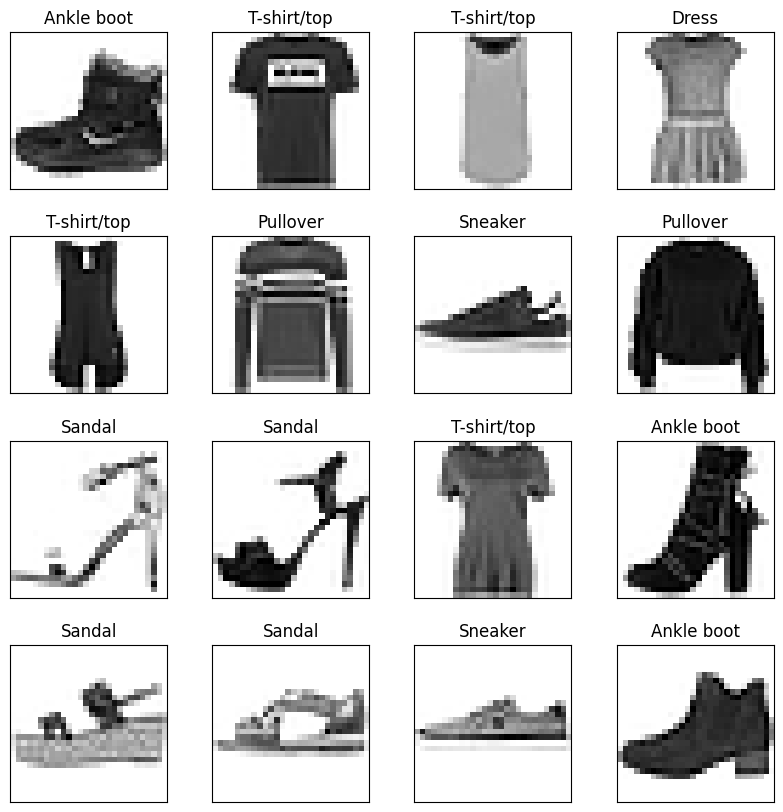

In [10]:
plt.figure(figsize=(10, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.subplots_adjust(hspace=.3)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.title(class_names[train_labels[i]])
plt.show()

In [11]:
# Architecting CNN model
# The CNN has two main components: The feature extractor composed of a set of convolutional and pooling layers and the classifier backend similar to a regular neural network

In [12]:
# we need to reshape the data into 4-dimensions
X_train = train_images.reshape((train_images.shape[0], 28, 28, 1))
X_test = test_images.reshape((test_images.shape[0], 28, 28, 1))
print(X_train.shape)

(60000, 28, 28, 1)


The first dimension is the number of samples


---
The fourth dimension is the appended one representing the grayscale images


In [13]:
# random seed in tensorflow for reproducility
tf.random.set_seed(42)
from tensorflow.keras import datasets, layers, models, losses
model = models.Sequential()
# add the first convolutional layers with 32 small-sized 3*3 filters
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# Convolutional layer is followed by a max-pooling layer with a 2*2 filter
model.add(layers.MaxPooling2D((2, 2)))
# second convolutional layer with 64 3*3 filters
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
# third convolutional layer with 128 3*3 filters
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
#The resulting filter maps are flatten to provide features to the downstream classifier backend
model.add(layers.Flatten())
#Classifier backend 
model.add(layers.Dense(64, activation='relu'))
#output with 10 nodes demonstrating 10 classes
model.add(layers.Dense(10, activation='softmax'))

model.compile(optimizer='adam',
              loss=losses.sparse_categorical_crossentropy,
              metrics=['accuracy'])

c:\Users\DAR_MR\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,114 (652.79 KB)

 Trainable params: 167,114 (652.79 KB)

 Non-trainable params: 0 (0.00 B)

The benefits of applying pooling are:


1.   avoiding overfitting
2.   Reducing training cost



In [15]:
model.fit(X_train, train_labels, validation_split=0.15, epochs=10, batch_size= 256) # batch size is 32 by default
# model.fit(X_train, train_labels, validation_data=(X_test, test_labels), epochs=10) # batch size is 32 by default

Epoch 1/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 59ms/step - accuracy: 0.7293 - loss: 0.7418 - val_accuracy: 0.7999 - val_loss: 0.5607
Epoch 2/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 56ms/step - accuracy: 0.8403 - loss: 0.4388 - val_accuracy: 0.8389 - val_loss: 0.4451
Epoch 3/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 12s 58ms/step - accuracy: 0.8671 - loss: 0.3700 - val_accuracy: 0.8660 - val_loss: 0.3845
Epoch 4/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.8826 - loss: 0.3290 - val_accuracy: 0.8742 - val_loss: 0.3583
Epoch 5/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.8920 - loss: 0.3007 - val_accuracy: 0.8847 - val_loss: 0.3318
Epoch 6/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.8998 - loss: 0.2792 - val_accuracy: 0.8898 - val_loss: 0.3161
Epoch 7/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9056 - loss: 0.2619 - val_accuracy: 0.8937 - val_loss: 0.3066
Epoch 8/10
200/200 ━━━━━━━━━━━━━━━━━━━━ 11s 57ms/step - accuracy: 0.9106 - loss: 0.2475 - 

In [16]:
# 96% on training set and 91% on the testing set
# double check the performance
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set: ',test_acc)

313/313 - 1s - 4ms/step - accuracy: 0.9002 - loss: 0.2812
Accuracy on test set:  0.9002000093460083


In [17]:
predictions = model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [18]:
print(predictions[0])

[2.6926935e-07 2.5548454e-07 2.4196069e-08 2.5719910e-08 1.8142764e-07
 4.8778669e-04 4.4955351e-09 1.1832542e-03 2.4872181e-05 9.9830329e-01]


In [19]:
import numpy as np

print('Predicted label for the first test sample: ', np.argmax(predictions[0]))

Predicted label for the first test sample:  9


In [20]:
print('True label for the first test sample: ', test_labels[0])

True label for the first test sample:  9


In [21]:
def plot_image_prediction(i, images, predictions, labels, class_names):
    plt.subplot(1,2,1)
    plt.imshow(images[i], cmap=plt.cm.binary)
    prediction = np.argmax(predictions[i])
    color = 'blue' if prediction == labels[i] else 'red'
    plt.title(f"{class_names[labels[i]]} (predicted {class_names[prediction]})", color=color)
    plt.subplot(1,2,2)
    plt.grid(False)
    plt.xticks(range(10))
    plot = plt.bar(range(10), predictions[i], color="#777777")
    plt.ylim([0, 1])
    plot[prediction].set_color('red')
    plot[labels[i]].set_color('blue')
    plt.show()

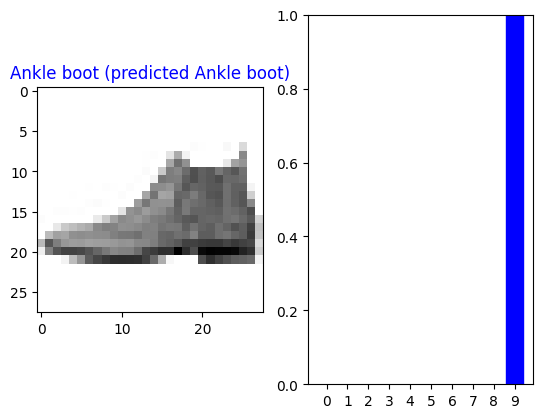

In [22]:
plot_image_prediction(0, test_images, predictions, test_labels, class_names)

In [23]:
model.layers[2].get_weights()[0].shape

(3, 3, 32, 64)

In [24]:
# 
filters, _ = model.layers[2].get_weights()
f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max-f_min)

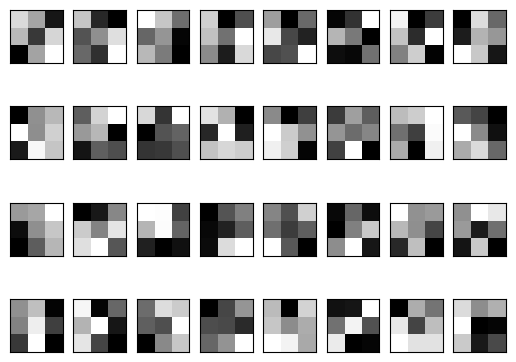

In [25]:
n_filters = 32
for i in range(n_filters):
  filter = filters[:, :, :, i]
  plt.subplot(4, 8, i+1)
  plt.xticks([])
  plt.yticks([])
  plt.imshow(filter[:, :, 0], cmap='gray')

plt.show()

In [26]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
n_small = 500
X_train = X_train[:n_small]
train_labels = train_labels[:n_small]
print(X_train.shape)

(500, 28, 28, 1)


In [28]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

In [29]:
model.compile(optimizer='adam',
               loss=losses.sparse_categorical_crossentropy,
               metrics=['accuracy'])

In [30]:
model.fit(X_train, train_labels, validation_data=(X_test, test_labels), epochs=20, batch_size=40)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - accuracy: 0.3520 - loss: 1.8611 - val_accuracy: 0.6008 - val_loss: 1.2701
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.6380 - loss: 0.9823 - val_accuracy: 0.6941 - val_loss: 0.8994
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.7120 - loss: 0.7815 - val_accuracy: 0.6986 - val_loss: 0.9249
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.7600 - loss: 0.6636 - val_accuracy: 0.7197 - val_loss: 0.8425
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.7720 - loss: 0.6362 - val_accuracy: 0.7546 - val_loss: 0.6966
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.8360 - loss: 0.5340 - val_accuracy: 0.7363 - val_loss: 0.7079
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.8420 - loss: 0.4361 - val_accuracy: 0.7512 - val_loss: 0.6901
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.8620 - loss: 0.3797 - val_accuracy: 0.7560 - 

In [31]:
test_loss, test_acc = model.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set:', test_acc)

313/313 - 1s - 5ms/step - accuracy: 0.7812 - loss: 0.8646
Accuracy on test set: 0.7811999917030334


The accuracy  without augmentation has a classification accuracy of 79.5%

In [32]:
datagen = ImageDataGenerator(height_shift_range=3,
                              horizontal_flip=True
                              )


In [33]:
model_aug = tf.keras.models.clone_model(model)

In [34]:
model_aug.compile(optimizer='adam',
               loss=losses.sparse_categorical_crossentropy,
               metrics=['accuracy'])

In [35]:
train_generator = datagen.flow(X_train, train_labels, seed=42, batch_size=40)

model_aug.fit(train_generator, epochs=50, validation_data=(X_test, test_labels))

Epoch 1/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 145ms/step - accuracy: 0.2960 - loss: 2.0612 - val_accuracy: 0.4961 - val_loss: 1.5977
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step - accuracy: 0.5420 - loss: 1.3392 - val_accuracy: 0.6401 - val_loss: 1.0361
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6380 - loss: 0.9618 - val_accuracy: 0.6574 - val_loss: 0.9282
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6660 - loss: 0.9147 - val_accuracy: 0.6704 - val_loss: 0.8841
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.6800 - loss: 0.8559 - val_accuracy: 0.6483 - val_loss: 0.9642
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.6820 - loss: 0.8320 - val_accuracy: 0.7110 - val_loss: 0.8197
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 114ms/step - accuracy: 0.7860 - loss: 0.7003 - val_accuracy: 0.7146 - val_loss: 0.8106
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.7500 - loss: 0.7069 - val_accuracy: 0.

In [36]:
test_loss, test_acc = model_aug.evaluate(X_test, test_labels, verbose=2)
print('Accuracy on test set: ',test_acc)

313/313 - 1s - 4ms/step - accuracy: 0.7807 - loss: 0.8542
Accuracy on test set:  0.7807000279426575
